In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# from kret_studies import *
# from kret_studies.notebook import *
# from kret_studies.complex import *

# logger = get_notebook_logger()

In [3]:
from waymo_agent.notebook_imports import *

In [4]:
from functools import cache

In [5]:
from waymo_agent import *
from waymo_agent.osmnx import *
from waymo_agent.data_classes import *
from waymo_agent.action_heuristic import *
from waymo_agent.graph_env import *
from waymo_agent.simulation import *
from waymo_agent.action_heuristic.heuristic_simple import PricingAgent, DispatchAgent, RepositionAgent
from waymo_agent.models.ppo_model import RideShareActorCritic

In [ ]:
from waymo_agent.models.ppo_model import *
from waymo_agent.models.evaluate import *

In [7]:
from kret_sandbox.VIS import dtt
from kret_sandbox.exp_decay import exp_decay_half_life, get_gamma_from_half_life

In [ ]:
def get_obs_tuple(env: RideShareEnv):
    veh = env.observation_curr["vehicles"]
    req = env.observation_curr["pending_requests"]
    rides = env.observation_curr["active_rides"]
    return veh, req, rides


def get_obs_tuple_from_obs(obs: ObservationDict):
    veh = obs["vehicles"]
    req = obs["pending_requests"]
    rides = obs["active_rides"]
    return veh, req, rides

# Run Sim

In [47]:
from waymo_agent.models.evaluate import *

### Heuristic Agents

In [52]:
env_cfg = EnvConfig(max_episode_steps=60 * 3)
plt_cfg = PlotConfig()
env_heuristic = RideShareEnv(env_cfg, plot_config=plt_cfg)

Assigned lambda values to nodes. Total lambda: 2.3735 (target: 2.3460)


In [53]:
price_agent = PricingAgent(env_heuristic.config)
dispatch_agent = DispatchAgent(env_heuristic)
reposition_agent = RepositionAgent(env_heuristic)
agents = (price_agent, dispatch_agent, reposition_agent)

### Actor-Critic PPO Model

In [54]:
# env_cfg = EnvConfig(max_episode_steps=60 * 3)
plt_cfg = PlotConfig()
env_model = RideShareEnv(env_cfg, plt_cfg)

Assigned lambda values to nodes. Total lambda: 2.1605 (target: 2.3460)


In [ ]:
cfg_ppo = PPOTrainConfig()
model = RideShareActorCritic(env_model)
load_weights(model, MODEL_WEIGHT_DIR / "ppo_model_final.pt", DEVICE_TORCH_STR)

RideShareActorCritic(
  (encoder): Sequential(
    (0): Linear(in_features=944, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
  )
  (price_mu): Linear(in_features=256, out_features=50, bias=True)
  (repo_mu): Linear(in_features=256, out_features=48, bias=True)
  (dispatch_logits): Linear(in_features=256, out_features=1250, bias=True)
  (value): Linear(in_features=256, out_features=1, bias=True)
)

In [48]:
r, info = run_episode(
    env_model,
    policy_fn=ppo_policy_stochastic(model),
    seed=0,
    show_progress=True,
    desc="PPO rollout",
)
r

PPO rollout:   0%|          | 0/180 [00:00<?, ?step/s]

-935.6666541155782

In [49]:
r, info = run_episode(
    env_heuristic,
    policy_fn=heuristic_policy(agents),
    seed=0,
    show_progress=True,
    desc="Heuristic rollout",
)

Heuristic rollout:   0%|          | 0/180 [00:00<?, ?step/s]

In [50]:
seeds = list(range(5))
results = eval_paired_seeds(
    env_model,
    env_heuristic,
    ppo_policy_stochastic(model),  # policy fn
    heuristic_policy(agents),  # policy fn
    seeds=seeds,
)
results

Evaluating policies:   0%|          | 0/5 [00:00<?, ?episode/s]

{'seeds': array([0, 1, 2, 3, 4]),
 'ppo': array([ -896.81208001,  -936.33749693,  -981.03857841,  -986.12523647,
        -1000.88083416]),
 'heur': array([247.78166477, 352.60164218, 278.76417276, 205.70805266,
        197.40143797]),
 'diff': array([-1144.59374478, -1288.9391391 , -1259.80275117, -1191.83328913,
        -1198.28227213]),
 'ppo_mean': -960.2388451974291,
 'ppo_std': 42.86237981373407,
 'heur_mean': 256.45139406766765,
 'heur_std': 63.007298233095725,
 'diff_mean': -1216.6902392650968,
 'diff_std': 57.5178623372858,
 'win_rate': 0.0}

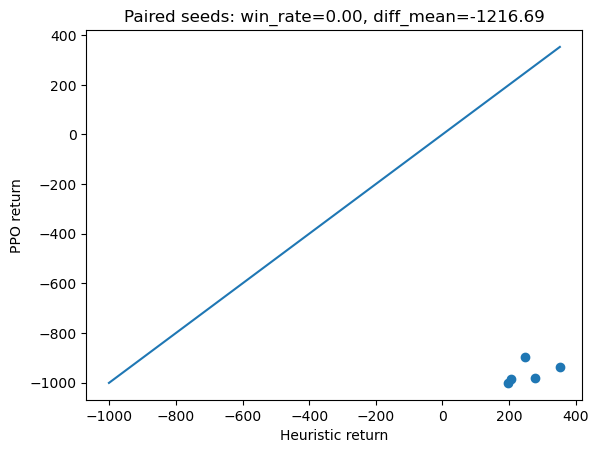

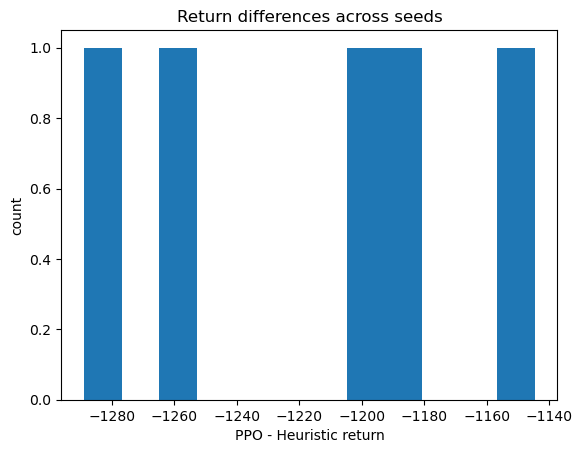

In [51]:
plot_min_eval(results)

In [44]:
results.keys()

dict_keys(['seeds', 'ppo', 'heur', 'diff', 'ppo_mean', 'ppo_std', 'heur_mean', 'heur_std', 'diff_mean', 'diff_std', 'win_rate'])